# TRABAJO PRÁCTICO DE CLUSTERING: CONSIGNAS

**Duran Juan Jose**

## Utilizando solo Numpy y Scikit-learn, y opcionalmente Pandas y Matplotlib, debes realizar  lo siguiente sobre el conjunto de datos de California Housing:

## 1. Analiza los datos, inspecciona todas las características y el target.

**Explica de que trata el dataset, cada una de sus variables**

**Asegúrate de preparar los datos para utilizarse en modelos  predictivos.**

**Puedes hacer el preprocesamiento de características  (selección, transformación) que consideres más adecuado, justificar.**

Fuente del dataset: https://www.kaggle.com/datasets/camnugent/california-housing-prices



**ACERCA DEL DATASET:**

El dataset posee datos acerca de las viviendas en California, obtenidos de un  censo realizado en 1990.

Las caracteristicas son:

1. longitude: mide cuan al oeste se ubica la vivienda, cuanto mas alto es el valor, mas alejada al oeste es su ubicacion;

2. latitude: mide cuan al norte se ubica la vivienda, cuanto mas alto es el valor, mas alejada al norte es su ubicacion;

3. housingMedianAge: antigüedad de la vivienda, un valor bajo indica que es mas nueva la construccion;

4. totalRooms: numero total de habitaciones dentro de una cuadra;

5. totalBedrooms: numero total de dormitorios dentro de una cuadra;

6. population: numero total de personas que viven por cuadra;

7. households: numero total de hogares, grupo de personas que viven por unidad dentro de una cuadra;

8. medianIncome: ingreso medio por hogar dentro de una cuadra (en miles de dolares);

9. medianHouseValue: valor medio de una vivienda por hogar dentro de una cuadra (medido en dolares);

10. oceanProximity: hubicacion de la vivienda, cercania al mar/oceano.

In [331]:
import kagglehub

# Descarga la última versión del dataset
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'california-housing-prices' dataset.
Path to dataset files: /kaggle/input/california-housing-prices


In [332]:
! ls /kaggle/input/california-housing-prices/*

/kaggle/input/california-housing-prices/housing.csv


In [333]:
import os
import pandas as pd


files_in_path = os.listdir(path)
print(f"Archivos en el directorio {path}: {files_in_path}")
ruta_al_archivo = path + "/" +files_in_path[0]

print(f"Cargando datos desde : {ruta_al_archivo}")
data= pd.read_csv(ruta_al_archivo)
print("DataFrame 'df' creado. Muestro las primeras 5 filas:")
display(data.head())


Archivos en el directorio /kaggle/input/california-housing-prices: ['housing.csv']
Cargando datos desde : /kaggle/input/california-housing-prices/housing.csv
DataFrame 'df' creado. Muestro las primeras 5 filas:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [334]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

In [335]:
df = pd.DataFrame(data)

df = df.rename(columns={'longitude':'Longitud',
                        'latitude':'Latitud',
                        'housing_median_age':'Antigüedad',
                        'total_rooms':'Habitaciones',
                        'total_bedrooms':'Dormitorios',
                        'population':'PersonasCuadra',
                        'households':'HogaresCuadra',
                        'median_income':'IngresoMedio',
                        'median_house_value':'ValorMedio',
                        'ocean_proximity':'ProximidadMar'})

print('Dataset renombrado:\n')
display(df.head())
print('\nDimension del dataset:\n')
print(f'Total de filas: {df.shape[0]}\nTotal de columnas: {df.shape[1]}')
print('\nInformacion del dataset:\n')
display(df.info())
print('\nResumen descriptivo de las variables numericas del dataset: \n')
display(df.describe())
print('\nComprobacion de valores nulos:\n')
display(df.isnull().sum())

Dataset renombrado:



,Longitud,Latitud,Antigüedad,Habitaciones,Dormitorios,PersonasCuadra,HogaresCuadra,IngresoMedio,ValorMedio,ProximidadMar
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Dimension del dataset:

Total de filas: 20640
Total de columnas: 10

Informacion del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Longitud        20640 non-null  float64
 1   Latitud         20640 non-null  float64
 2   Antigüedad      20640 non-null  float64
 3   Habitaciones    20640 non-null  float64
 4   Dormitorios     20433 non-null  float64
 5   PersonasCuadra  20640 non-null  float64
 6   HogaresCuadra   20640 non-null  float64
 7   IngresoMedio    20640 non-null  float64
 8   ValorMedio      20640 non-null  float64
 9   ProximidadMar   20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None


Resumen descriptivo de las variables numericas del dataset: 



,Longitud,Latitud,Antigüedad,Habitaciones,Dormitorios,PersonasCuadra,HogaresCuadra,IngresoMedio,ValorMedio
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



Comprobacion de valores nulos:



,0
Longitud,0
Latitud,0
Antigüedad,0
Habitaciones,0
Dormitorios,207
PersonasCuadra,0
HogaresCuadra,0
IngresoMedio,0
ValorMedio,0
ProximidadMar,0


**PREPROCESAMIENTO DE LOS DATOS**

Al observar los valores nulos, se puede apreciar que la variable "Dormitorios" cuenta con valores nulos, teniendo en cuenta que el dataset tiene mas de 20 registros y que los valores nulos de la variable son solo 207, se procedera a eliminar esos valores ya que solo significa el 1% de los datos del dataset.

In [336]:
df_cleaned = df.dropna(subset=['Dormitorios'])
print('Dataset limpio de valores nulos:\n')
display(df_cleaned.info())

Dataset limpio de valores nulos:

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Longitud        20433 non-null  float64
 1   Latitud         20433 non-null  float64
 2   Antigüedad      20433 non-null  float64
 3   Habitaciones    20433 non-null  float64
 4   Dormitorios     20433 non-null  float64
 5   PersonasCuadra  20433 non-null  float64
 6   HogaresCuadra   20433 non-null  float64
 7   IngresoMedio    20433 non-null  float64
 8   ValorMedio      20433 non-null  float64
 9   ProximidadMar   20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


None

Se realizara un One-Hot-Encoding para la variable "ProximidadMar", ya que es una variable categorica. El objetivo es crear las variables numericas necesarias y eliminar las que no posean datos. Se vera que no existen registros para la variable "<1H OCEAN" por lo tanto no aparecera en el cuadro transformado.

In [337]:
print('Valores unicos de la variable "ProximidadMar":\n')

for _ in df_cleaned['ProximidadMar'].unique():
  print(_)

Valores unicos de la variable "ProximidadMar":

NEAR BAY
<1H OCEAN
INLAND
NEAR OCEAN
ISLAND


In [338]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['ProximidadMar'], drop_first=True, dtype=int)
print('Dataset con One-Hot-Encoding:\n')
display(df_cleaned.head())

Dataset con One-Hot-Encoding:



,Longitud,Latitud,Antigüedad,Habitaciones,Dormitorios,PersonasCuadra,HogaresCuadra,IngresoMedio,ValorMedio,ProximidadMar_INLAND,ProximidadMar_ISLAND,ProximidadMar_NEAR BAY,ProximidadMar_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [339]:
df_cleaned = df_cleaned.rename(columns={'ProximidadMar_<1H OCEAN':'>1HOcean',
                                        'ProximidadMar_INLAND':'Inland',
                                        'ProximidadMar_ISLAND':'Island',
                                        'ProximidadMar_NEAR BAY':'NearBay',
                                        'ProximidadMar_NEAR OCEAN':'NearOcean'})#.astype(float)

df_cleaned.astype(float)
print('Dataset renombrado:\n')
display(df_cleaned.head())

Dataset renombrado:



,Longitud,Latitud,Antigüedad,Habitaciones,Dormitorios,PersonasCuadra,HogaresCuadra,IngresoMedio,ValorMedio,Inland,Island,NearBay,NearOcean
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [340]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Longitud        20433 non-null  float64
 1   Latitud         20433 non-null  float64
 2   Antigüedad      20433 non-null  float64
 3   Habitaciones    20433 non-null  float64
 4   Dormitorios     20433 non-null  float64
 5   PersonasCuadra  20433 non-null  float64
 6   HogaresCuadra   20433 non-null  float64
 7   IngresoMedio    20433 non-null  float64
 8   ValorMedio      20433 non-null  float64
 9   Inland          20433 non-null  int64  
 10  Island          20433 non-null  int64  
 11  NearBay         20433 non-null  int64  
 12  NearOcean       20433 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 2.2 MB


Finalmente se procedera a escalar los datos con "StandardScaler" ya que todas las variables han quedado numericas.

In [341]:
df_scaled = df_cleaned.copy()

numerical_cols = ['Longitud', 'Latitud', 'Antigüedad', 'Habitaciones', 'Dormitorios', 'PersonasCuadra', 'HogaresCuadra', 'IngresoMedio', 'ValorMedio']

scaler = StandardScaler()
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print('Dataset escalado correctamente:\n')
display(df_scaled.head().round(1))

Dataset escalado correctamente:



,Longitud,Latitud,Antigüedad,Habitaciones,Dormitorios,PersonasCuadra,HogaresCuadra,IngresoMedio,ValorMedio,Inland,Island,NearBay,NearOcean
0,-1.3,1.1,1.0,-0.8,-1.0,-1.0,-1.0,2.3,2.1,0,0,1,0
1,-1.3,1.0,-0.6,2.0,1.3,0.9,1.7,2.3,1.3,0,0,1,0
2,-1.3,1.0,1.9,-0.5,-0.8,-0.8,-0.8,1.8,1.3,0,0,1,0
3,-1.3,1.0,1.9,-0.6,-0.7,-0.8,-0.7,0.9,1.2,0,0,1,0
4,-1.3,1.0,1.9,-0.5,-0.6,-0.8,-0.6,-0.0,1.2,0,0,1,0


## 2. Realiza un clustering sobre los datos con K-means, separándolos en un número manejable de  grupos (de 2 a 10).

2.1) Justifica cuál métrica ( o grupo de métricas) utilizas para determinar el valor de k.

2.2) Realiza un análisis descriptivo de cada clúster, grafica para cada uno diagrama cajas.

/tmp/ipykernel_554/633001090.py:12: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.scatterplot(x=X[:,0],y=X[:,1],hue=labels,legend='full',palette=sns.color_palette("hls", 5));


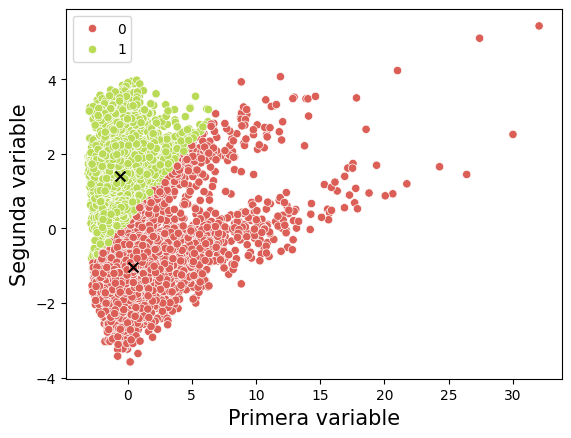

In [342]:
#Se realiza Analisis de Componentes Principales del dataframe ya escalado y se reducen las dimensiones a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

X=X_pca
kmeans=KMeans(n_clusters=2,random_state=0)
kmeans.fit(X)

labels = kmeans.labels_ # Etiquetas
centroids = kmeans.cluster_centers_ # Coordenadas de los centroides

sns.scatterplot(x=X[:,0],y=X[:,1],hue=labels,legend='full',palette=sns.color_palette("hls", 5));
plt.xlabel('Primera variable',fontsize=15);plt.ylabel('Segunda variable',fontsize=15);
plt.scatter(centroids[:,0],centroids[:,1],marker='x',s=50,color='k');

Utilice k=2 ya que, cuando se paso por PCA, solo quedaron 2 variables para el analisis.

Analisis descriptivo de los clusters: 



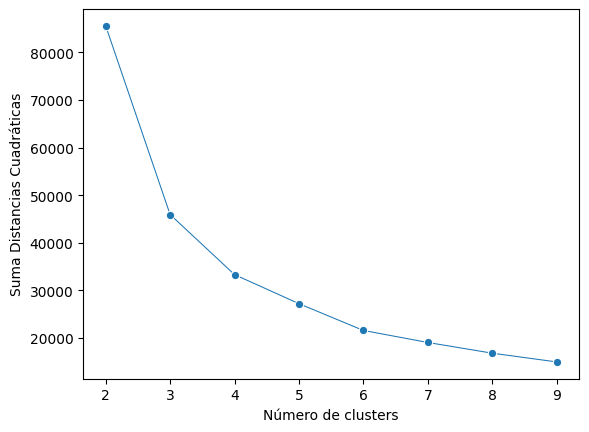

In [343]:
print('Analisis descriptivo de los clusters: \n')

sq_distances=[]
k_values=range(2,10);

for k in k_values:
    kmeans=KMeans(n_clusters=k,random_state=0)
    kmeans.fit(X)
    sq_distances.append(kmeans.inertia_)

sns.lineplot(x=k_values,y=sq_distances,marker='o',size=30,legend=False);
plt.ylabel('Suma Distancias Cuadráticas');
plt.xlabel('Número de clusters');



## 3. Aplica DB-SCAN sobre el mismo dataset que utilizaste en el punto 2.

Realiza una interpretación de su aplicación y un análisis de los resultados obtenidos.

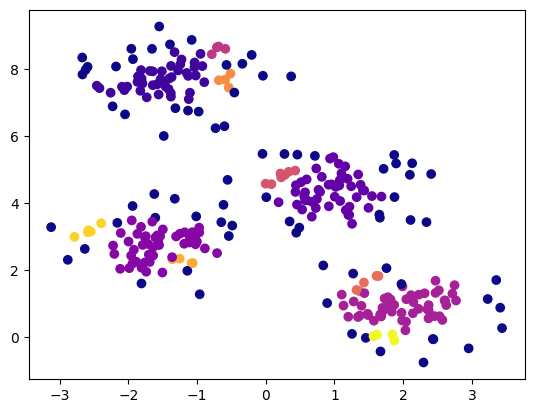

In [344]:
# Generar datos de ejemplo
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Aplicar DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X)

# Visualizar clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma')
plt.show()

# NO OLVIDES

Agregar tus conclusiones y referencias.